# Capstone Session 5

This notebook is generated from the copied `Capstone_Session_5.pdf` task list and the staged `FloridaBikeRentals.csv` dataset. It follows the same requirement-first workflow used across the FrancisBurnet capstone site.

## Objective

Predict hourly bike rental demand and compare Linear Regression, Lasso Regression, and Ridge Regression using the required preprocessing and exploratory analysis steps.

In [ ]:
from pathlib import Path
import json
import sys
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

IS_COLAB = 'google.colab' in sys.modules
GITHUB_REPO_OWNER = 'FrancisBurnet'
GITHUB_REPO_NAME = 'francisburnet'
GITHUB_REPO_BRANCH = 'main'
CAPSTONE_ROOT = Path('Incremental Capstones/Machine Learning Using Python/Capstone Session 5')
DATASET_FILENAME = 'FloridaBikeRentals.csv'


def build_raw_github_url(relative_path: Path) -> str:
    encoded_path = quote(relative_path.as_posix(), safe='/')
    return (
        f"https://raw.githubusercontent.com/{GITHUB_REPO_OWNER}/{GITHUB_REPO_NAME}/"
        f"{GITHUB_REPO_BRANCH}/{encoded_path}"
    )


def resolve_capstone_dir() -> Path | None:
    current = Path.cwd().resolve()
    capstone_parts = CAPSTONE_ROOT.parts
    for candidate in [current, *current.parents]:
        if len(candidate.parts) >= len(capstone_parts) and candidate.parts[-len(capstone_parts):] == capstone_parts:
            return candidate
        nested_candidate = candidate / CAPSTONE_ROOT
        if nested_candidate.exists():
            return nested_candidate
    return None


CAPSTONE_DIR = resolve_capstone_dir()
DATASET_URL = build_raw_github_url(CAPSTONE_ROOT / DATASET_FILENAME)

if CAPSTONE_DIR is not None:
    OUTPUT_ROOT = CAPSTONE_DIR
    OUTPUT_MODE = 'permanent capstone outputs'
    OUTPUT_DISPLAY = (CAPSTONE_ROOT / 'outputs').as_posix()
else:
    runtime_root = Path('/content/capstone-session-5-runtime') if IS_COLAB else Path.cwd().resolve() / 'capstone-session-5-runtime'
    OUTPUT_ROOT = runtime_root
    OUTPUT_MODE = 'runtime scratch outputs; export final artifacts back into the capstone outputs folder'
    OUTPUT_DISPLAY = 'capstone-session-5-runtime/outputs'

OUTPUTS_DIR = (OUTPUT_ROOT / 'outputs').resolve()
PLOTS_DIR = OUTPUTS_DIR / 'plots'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

print('Runtime:', 'Google Colab' if IS_COLAB else 'Notebook runtime')
print('Capstone artifact path:', CAPSTONE_ROOT.as_posix())
print('Dataset source:', DATASET_URL)
print('Output mode:', OUTPUT_MODE)
print('Output target:', OUTPUT_DISPLAY)

Runtime: Local / notebook runtime
Base directory: x:\SIMPLILEARN\FrancisBurnetCom\Incremental Capstones\Machine Learning Using Python\Capstone Session 5
Dataset path: x:\SIMPLILEARN\FrancisBurnetCom\Incremental Capstones\Machine Learning Using Python\Capstone Session 5\FloridaBikeRentals.csv


## Load and audit the staged dataset

In [ ]:
df = pd.read_csv(DATASET_URL, encoding='latin1')
df.columns = [column.replace('�', '°').strip() for column in df.columns]
display(df.head())
print('Dataset source used:', DATASET_URL)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
null_counts = df.isna().sum().sort_values(ascending=False)
display(null_counts[null_counts > 0])

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


Shape: (8760, 14)
Columns: ['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


Series([], dtype: int64)

## Feature engineering from the required date column

In [3]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.day_name()
df['is_weekend'] = df['Date'].dt.dayofweek >= 5
display(df[['Date', 'day', 'month', 'day_of_week', 'is_weekend']].head())

,Date,day,month,day_of_week,is_weekend
0,2017-12-01,1,12,Friday,False
1,2017-12-01,1,12,Friday,False
2,2017-12-01,1,12,Friday,False
3,2017-12-01,1,12,Friday,False
4,2017-12-01,1,12,Friday,False


## Required exploratory analysis plots

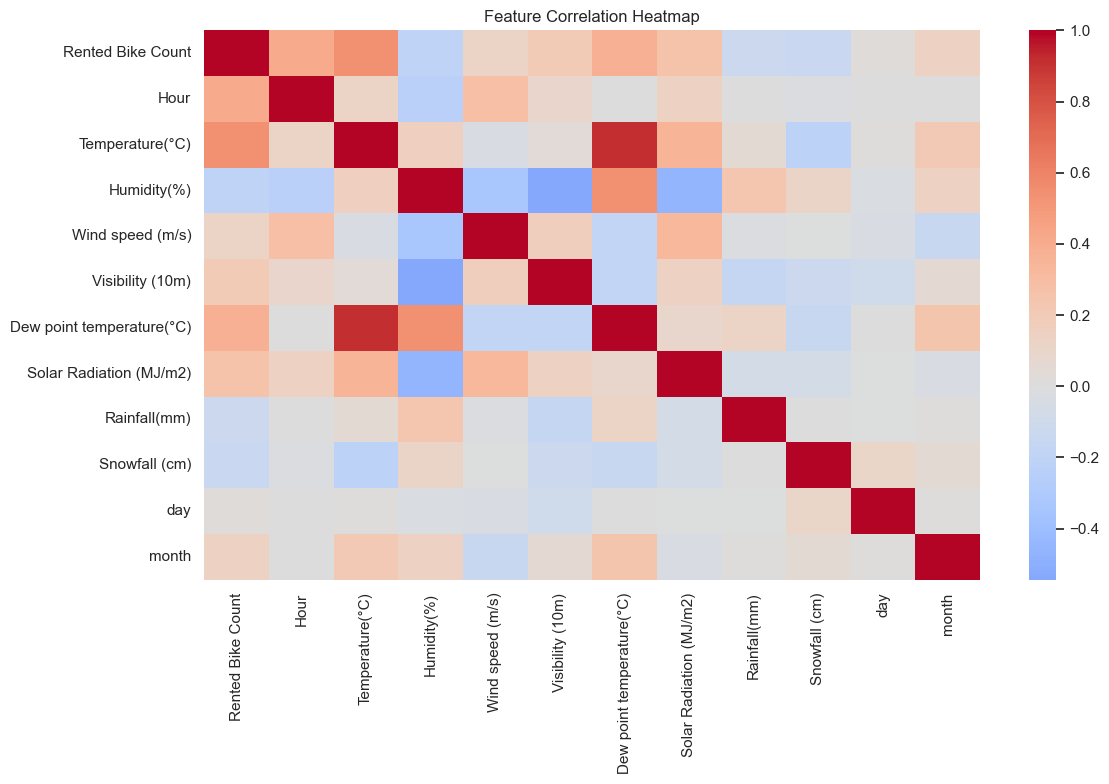

In [4]:
numeric_df = df.select_dtypes(include=['number']).copy()
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(numeric_df.corr(numeric_only=True), cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()
plt.close(fig)

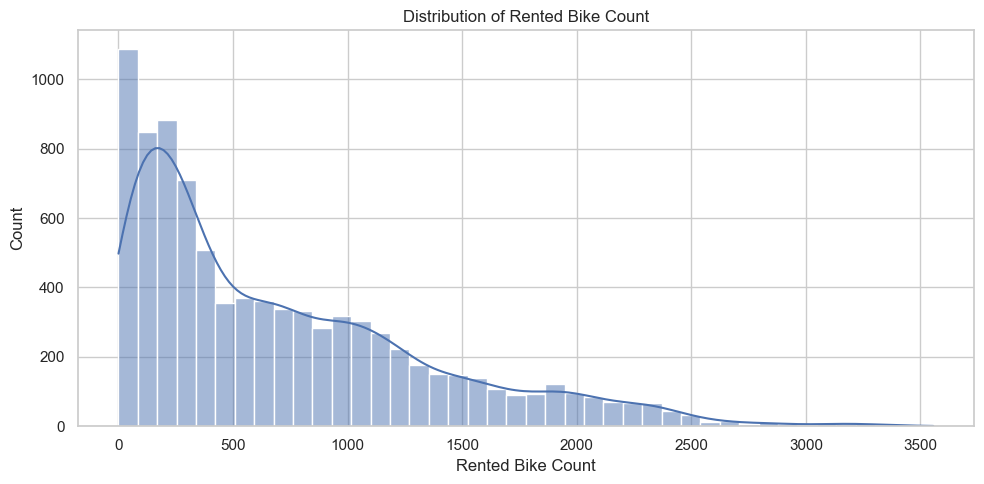

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Rented Bike Count'], kde=True, ax=ax)
ax.set_title('Distribution of Rented Bike Count')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'rented_bike_count_distribution.png', dpi=150)
plt.show()
plt.close(fig)

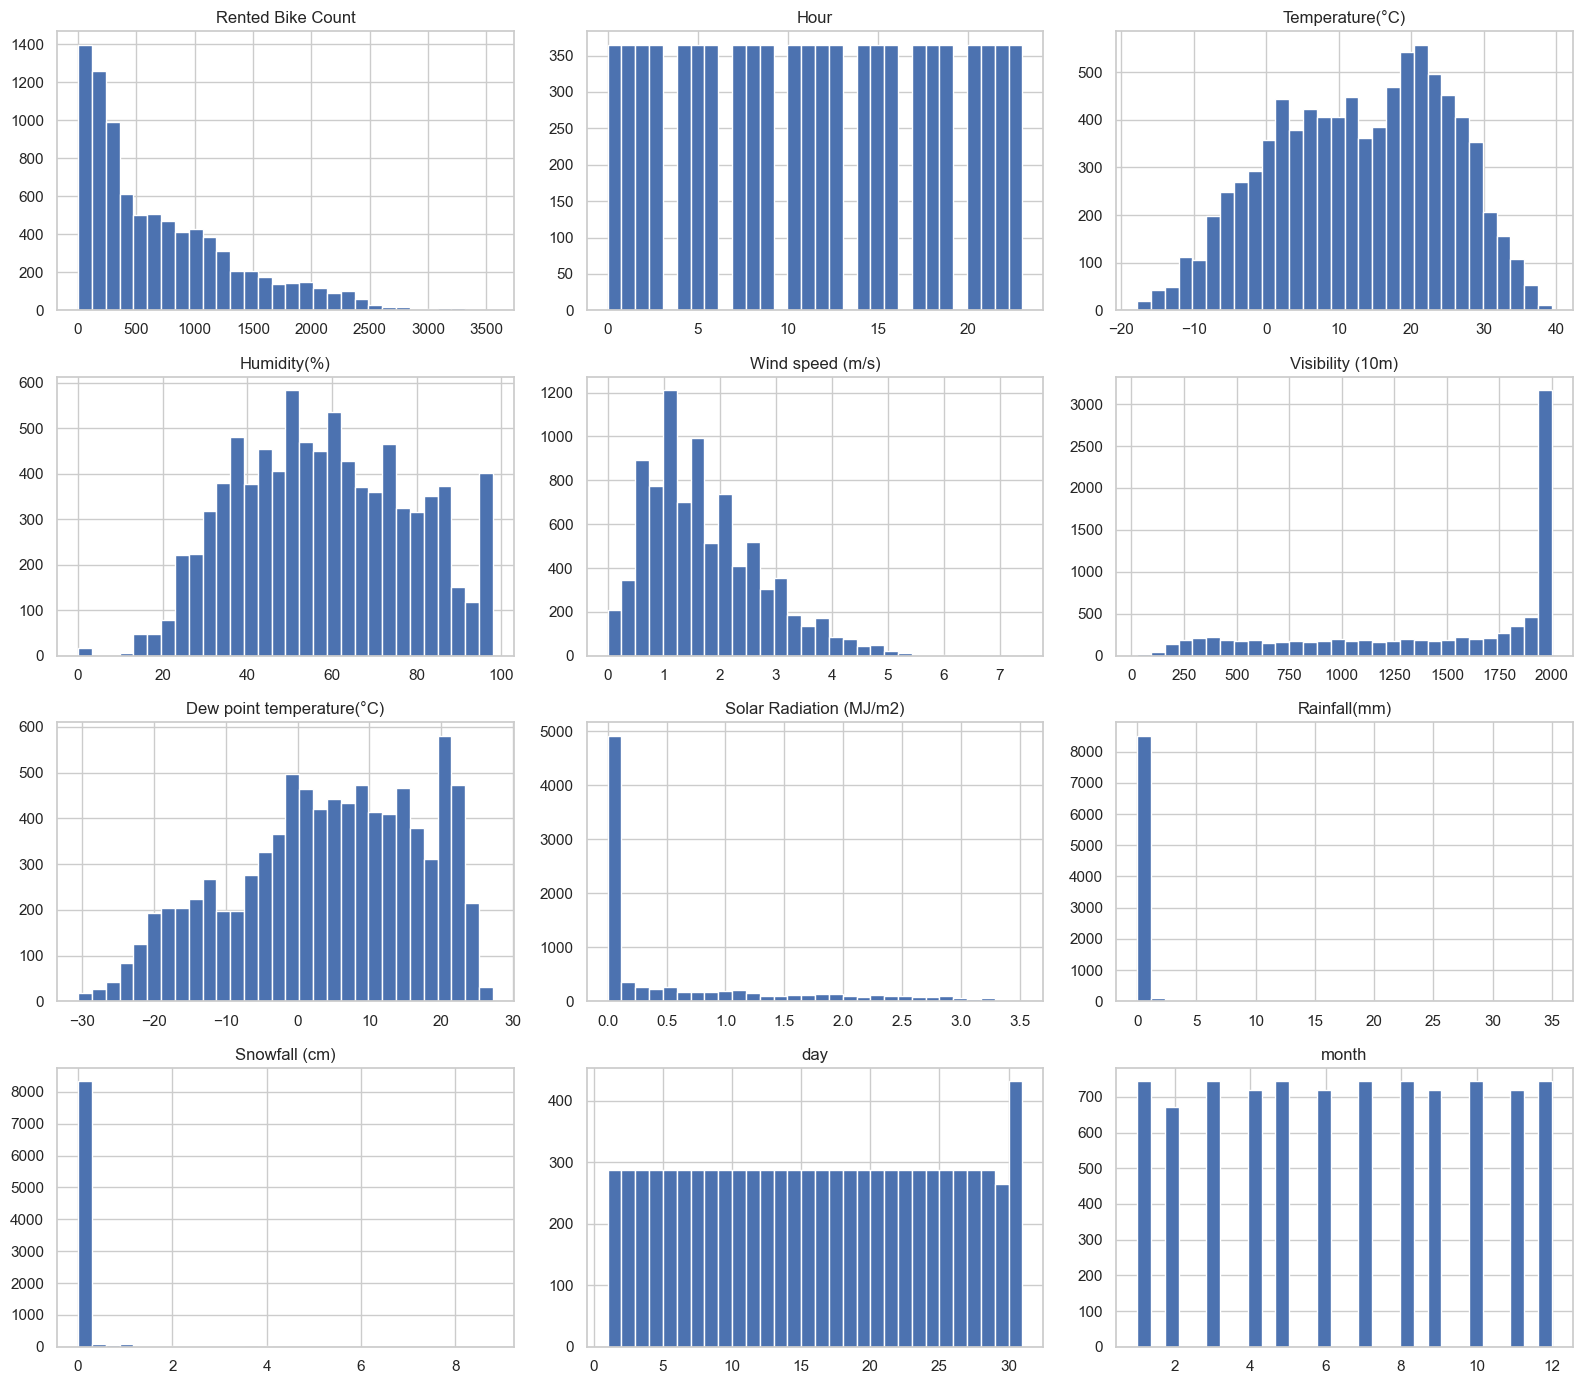

In [6]:
fig = df.select_dtypes(include=['number']).hist(figsize=(16, 14), bins=30)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'numeric_feature_histograms.png', dpi=150)
plt.show()
plt.close('all')

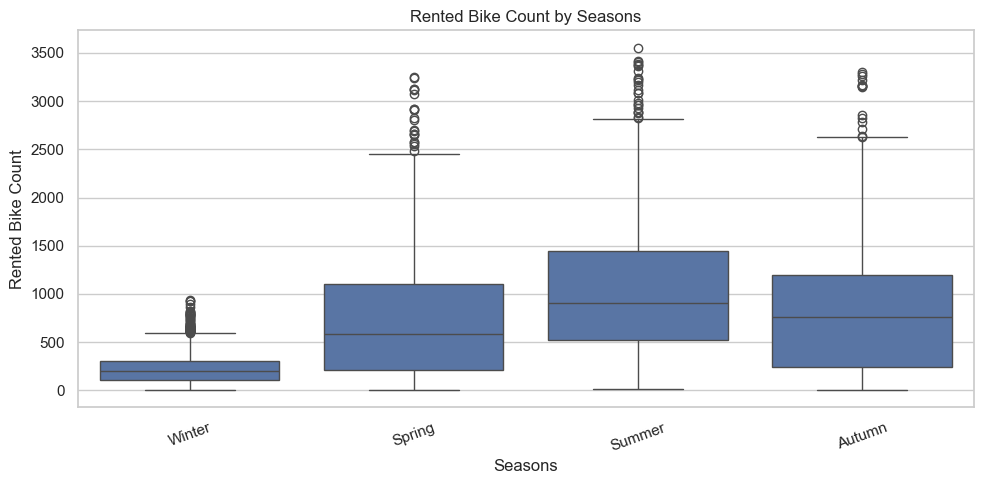

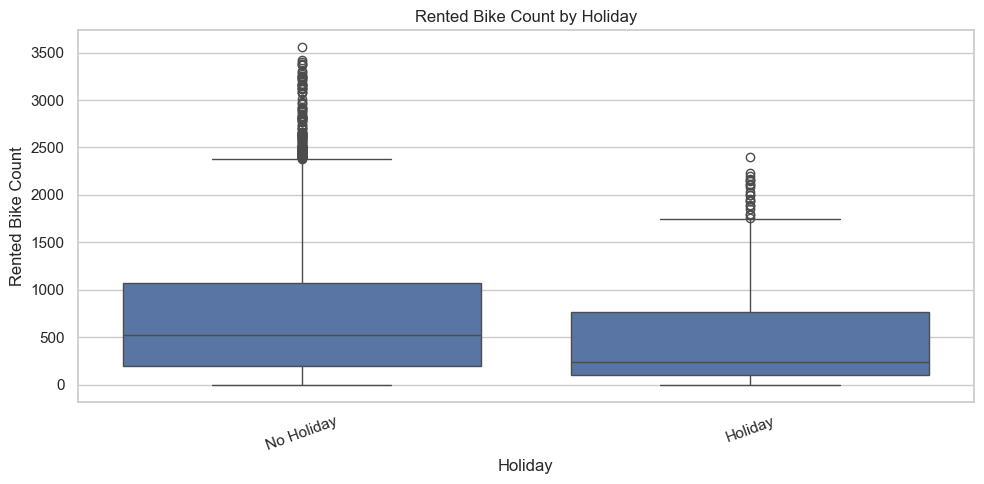

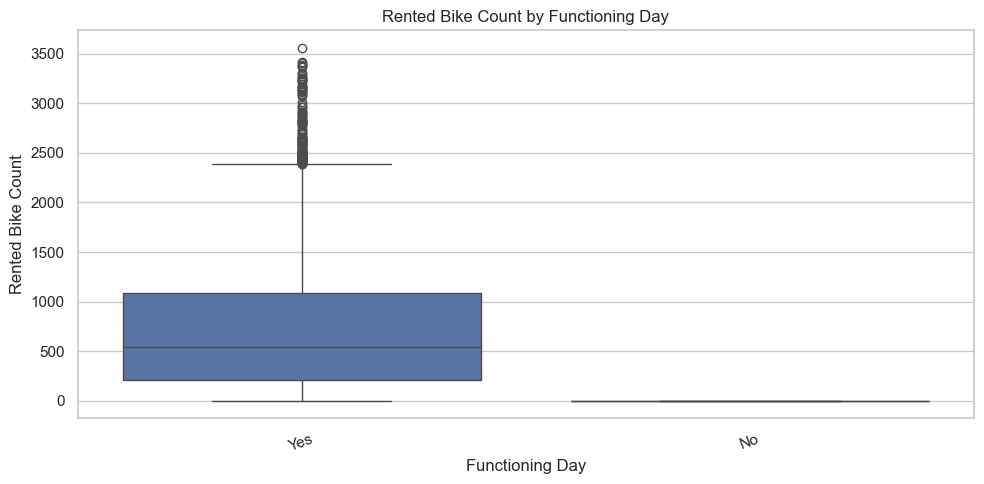

In [7]:
for column in ['Seasons', 'Holiday', 'Functioning Day']:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x=column, y='Rented Bike Count', ax=ax)
    ax.set_title(f'Rented Bike Count by {column}')
    ax.tick_params(axis='x', rotation=20)
    fig.tight_layout()
    safe_name = column.lower().replace(' ', '_')
    fig.savefig(PLOTS_DIR / f'boxplot_{safe_name}.png', dpi=150)
    plt.show()
    plt.close(fig)

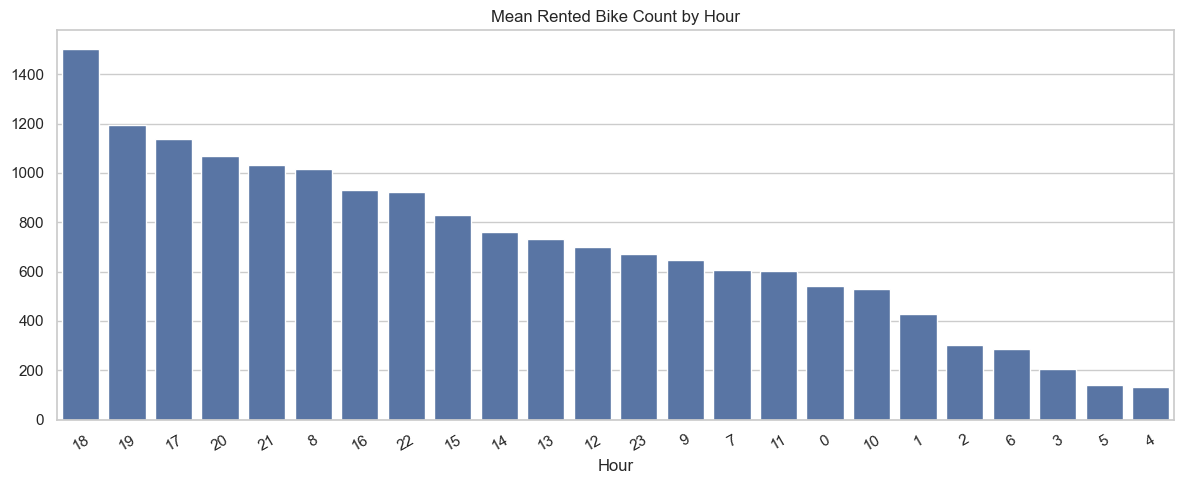

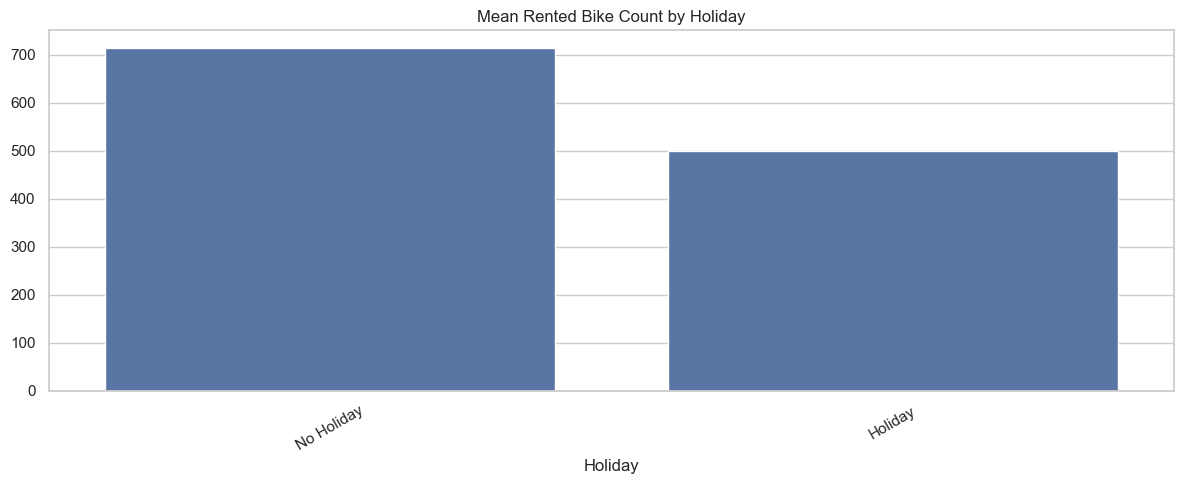

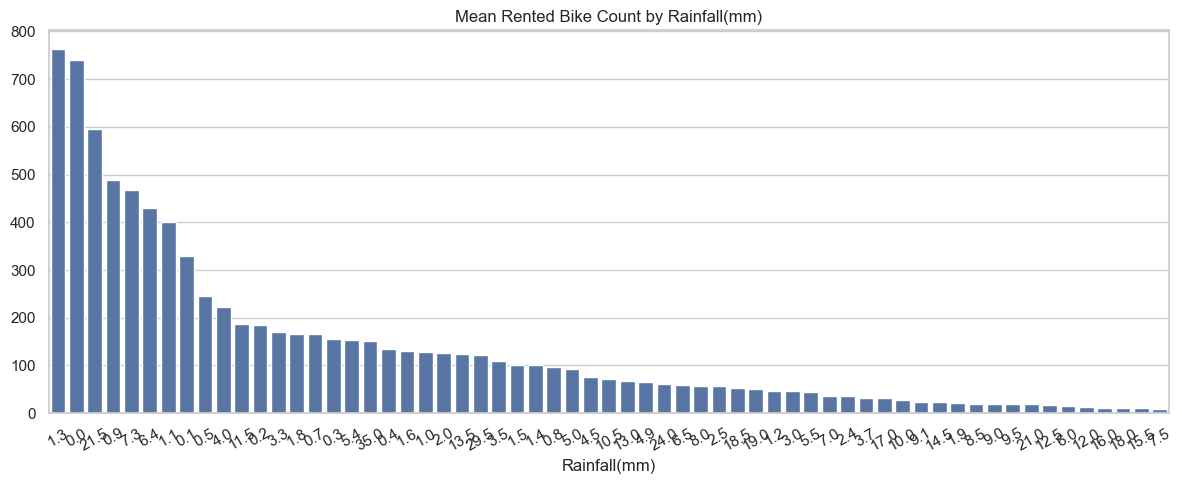

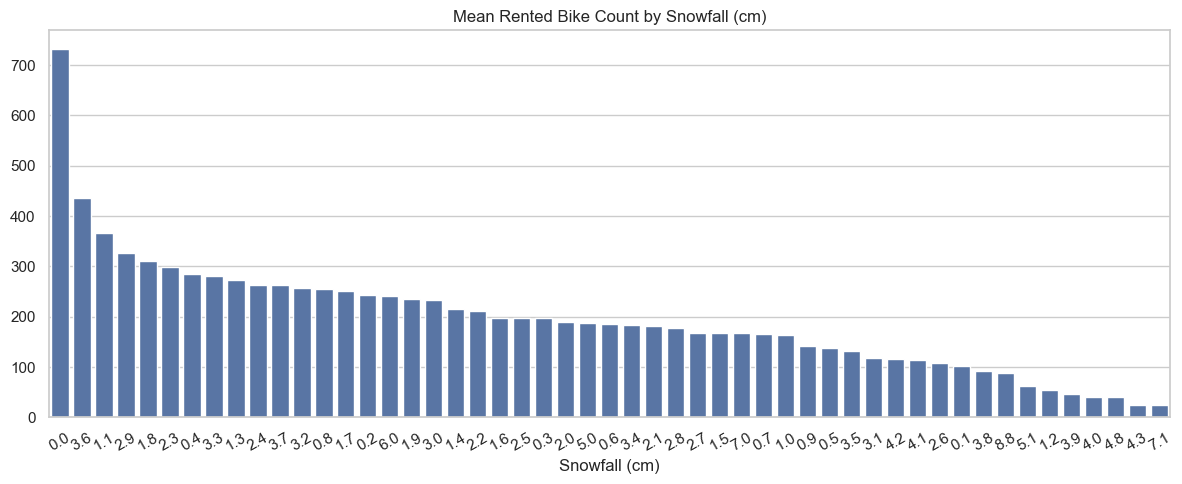

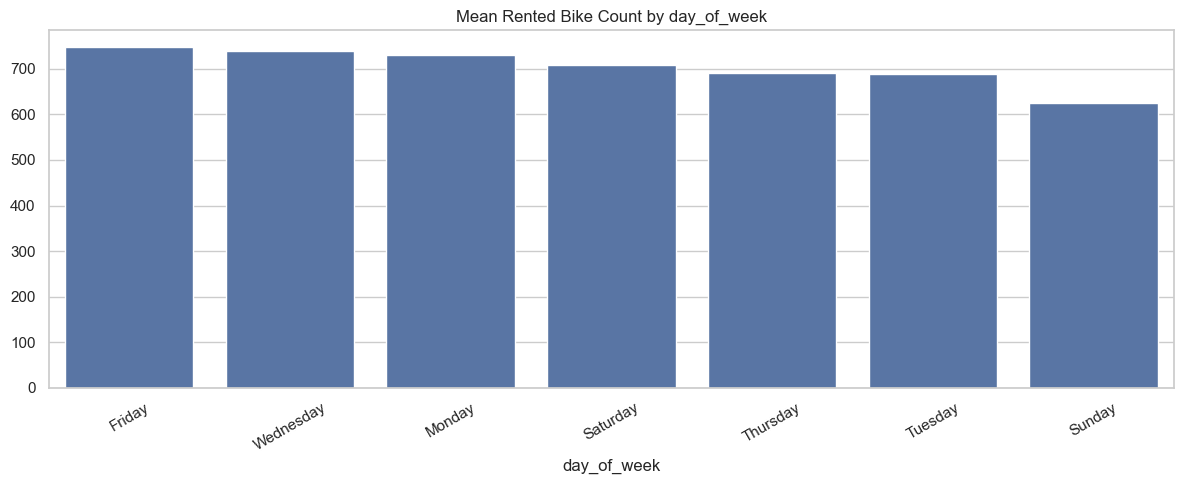

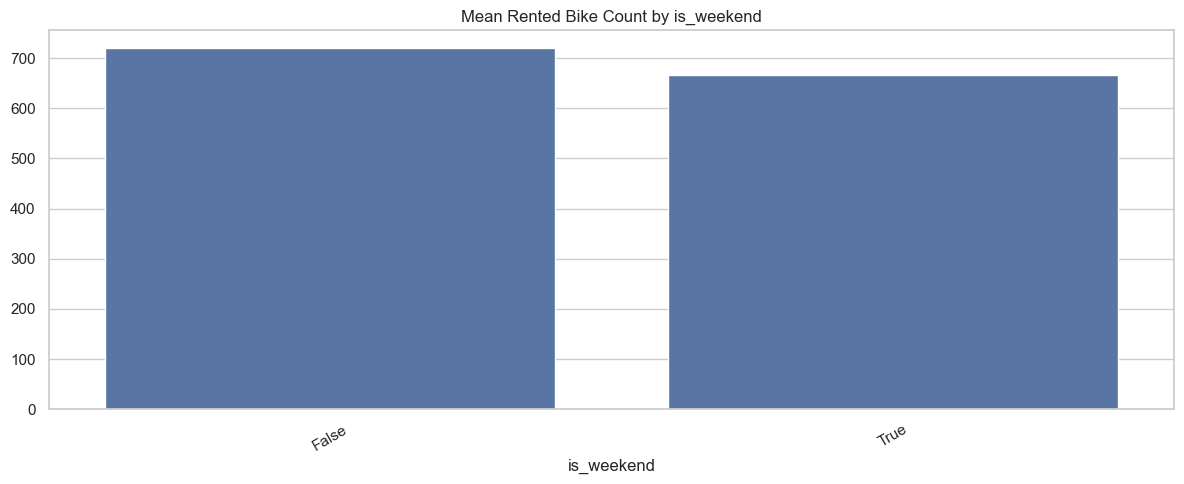

,feature,highest_mean_group,highest_mean_value,lowest_mean_group,lowest_mean_value
0,Hour,18,1502.926,4,132.592
1,Holiday,No Holiday,715.228,Holiday,499.757
2,Rainfall(mm),1.3,764.000,7.5,9.000
3,Snowfall (cm),0.0,732.273,7.1,24.000
4,day_of_week,Friday,747.118,Sunday,625.155
5,is_weekend,False,719.449,True,667.342


In [8]:
catplot_specs = [
    ('Hour', 'hour'),
    ('Holiday', 'holiday'),
    ('Rainfall(mm)', 'rainfall'),
    ('Snowfall (cm)', 'snowfall'),
    ('day_of_week', 'day_of_week'),
    ('is_weekend', 'is_weekend'),
]
inferences = []
for column, slug in catplot_specs:
    fig, ax = plt.subplots(figsize=(12, 5))
    grouped = df.groupby(column, dropna=False)['Rented Bike Count'].mean().sort_values(ascending=False)
    sns.barplot(x=grouped.index.astype(str), y=grouped.values, ax=ax)
    ax.set_title(f'Mean Rented Bike Count by {column}')
    ax.tick_params(axis='x', rotation=30)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f'catplot_{slug}.png', dpi=150)
    plt.show()
    plt.close(fig)
    inferences.append({
        'feature': column,
        'highest_mean_group': str(grouped.index[0]),
        'highest_mean_value': round(float(grouped.iloc[0]), 3),
        'lowest_mean_group': str(grouped.index[-1]),
        'lowest_mean_value': round(float(grouped.iloc[-1]), 3),
    })
display(pd.DataFrame(inferences))

## Modeling

The PDF requires `get_dummies()`, an 80:20 split with `random_state=1`, standard scaling, and comparison of Linear Regression, Lasso Regression, and Ridge Regression. The PDF does not specify regularization strengths, so the notebook uses sklearn defaults for Lasso and Ridge and records that choice in the summary output.

In [9]:
target = 'Rented Bike Count'
feature_df = df.drop(columns=['Date'])
X = feature_df.drop(columns=[target])
y = feature_df[target]
categorical_columns = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_columns = [column for column in X.columns if column not in categorical_columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
encoded_preview = pd.get_dummies(X, columns=categorical_columns, drop_first=False)
display(encoded_preview.head())

Train shape: (7008, 16) Test shape: (1752, 16)


C:\Users\franc\AppData\Local\Temp\ipykernel_62656\4026604946.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=['object', 'bool']).columns.tolist()


,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),day,month,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,is_weekend_False,is_weekend_True
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,True,False
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,True,False
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,True,False
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,True,False
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,True,False


In [10]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
}

results = []
prediction_frames = []
for name, estimator in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, predictions)))
    mae = float(mean_absolute_error(y_test, predictions))
    r2 = float(r2_score(y_test, predictions))
    results.append({'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2})
    prediction_frames.append(pd.DataFrame({
        'model': name,
        'actual': y_test.reset_index(drop=True),
        'predicted': pd.Series(predictions),
    }).head(25))

results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
display(results_df)
best_model = results_df.iloc[0].to_dict()
print('Best model by RMSE:', best_model['model'])

,model,rmse,mae,r2
0,Lasso Regression,430.296819,319.643529,0.551997
1,Ridge Regression,430.788278,320.336715,0.550973
2,Linear Regression,430.803271,320.359317,0.550942


Best model by RMSE: Lasso Regression


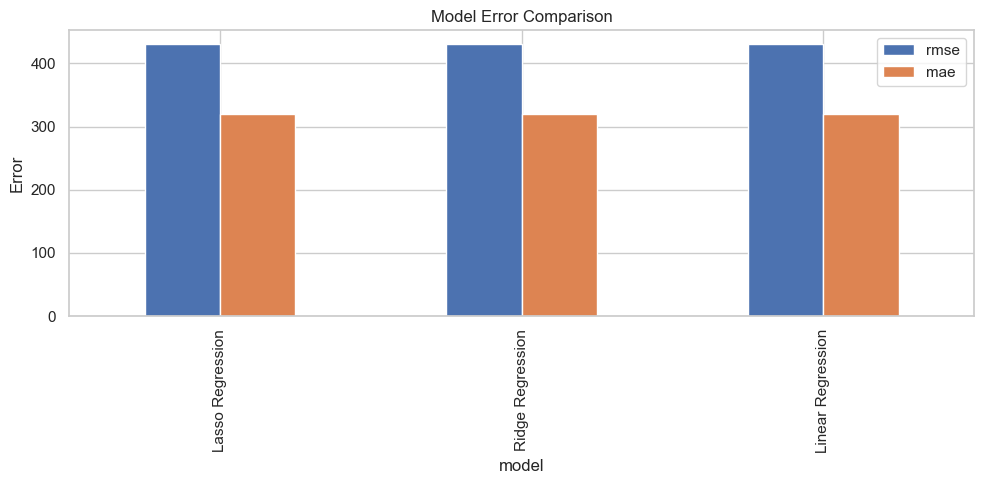

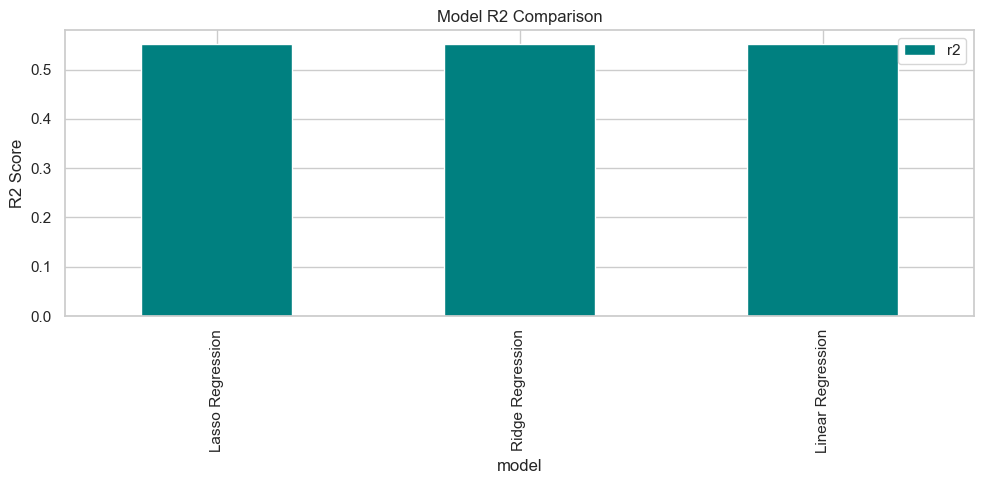

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(x='model', y=['rmse', 'mae'], kind='bar', ax=ax)
ax.set_title('Model Error Comparison')
ax.set_ylabel('Error')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'model_error_comparison.png', dpi=150)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(x='model', y='r2', kind='bar', color='teal', ax=ax)
ax.set_title('Model R2 Comparison')
ax.set_ylabel('R2 Score')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'model_r2_comparison.png', dpi=150)
plt.show()
plt.close(fig)

In [12]:
results_df.to_csv(OUTPUTS_DIR / 'session_5_model_metrics.csv', index=False)
pd.concat(prediction_frames, ignore_index=True).to_csv(OUTPUTS_DIR / 'session_5_prediction_samples.csv', index=False)
summary = {
    'dataset_shape': list(df.shape),
    'train_rows': int(X_train.shape[0]),
    'test_rows': int(X_test.shape[0]),
    'target': target,
    'categorical_columns': categorical_columns,
    'numeric_columns': numeric_columns,
    'model_results': results,
    'best_model': best_model,
    'catplot_inferences': inferences,
    'notes': [
        'Categorical features are encoded with pd.get_dummies() preview and pipeline one-hot encoding for model training.',
        'Lasso and Ridge use sklearn default alpha values because the PDF does not specify hyperparameters.',
    ],
}
with open(OUTPUTS_DIR / 'session_5_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary

{'dataset_shape': [8760, 18],
 'train_rows': 7008,
 'test_rows': 1752,
 'target': 'Rented Bike Count',
 'categorical_columns': ['Seasons',
  'Holiday',
  'Functioning Day',
  'day_of_week',
  'is_weekend'],
 'numeric_columns': ['Hour',
  'Temperature(°C)',
  'Humidity(%)',
  'Wind speed (m/s)',
  'Visibility (10m)',
  'Dew point temperature(°C)',
  'Solar Radiation (MJ/m2)',
  'Rainfall(mm)',
  'Snowfall (cm)',
  'day',
  'month'],
 'model_results': [{'model': 'Linear Regression',
   'rmse': 430.80327132329893,
   'mae': 320.3593174193256,
   'r2': 0.5509419599562837},
  {'model': 'Lasso Regression',
   'rmse': 430.29681892846634,
   'mae': 319.64352934565517,
   'r2': 0.5519971647497581},
  {'model': 'Ridge Regression',
   'rmse': 430.78827825169327,
   'mae': 320.33671540137607,
   'r2': 0.5509732161822174}],
 'best_model': {'model': 'Lasso Regression',
  'rmse': 430.29681892846634,
  'mae': 319.64352934565517,
  'r2': 0.5519971647497581},
 'catplot_inferences': [{'feature': 'Hour',


## Conclusion

This notebook stages the required exploratory analysis, encoding preview, model comparison, and saved artifacts for the website workflow. The plot files and summary outputs in `outputs/` are the evidence layer the custom Session 5 page can surface next.